# Importance sampling comparison

Function initialization:

In [1]:
from QMC_option_pricing import european_call_cf, european_call_mc, european_call_is

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

def logyfit(X,Y):
    X
    logY = np.log(Y)

    # linear fit: logY = a * logx + logC
    a, logC = np.polyfit(X, logY, 1)

    C = np.exp(logC)
    return a, C

%matplotlib inline

Parameters:

In [2]:
S0 = 100      # spot
# K = 100     # at-the-money strike
T = 1         # 1 year
r = 0.05      # 5% risk-free rate
sigma = 0.20  # 20% volatility
n = int(1e5)
exp = 100
maxiter = 10
step = 20

## Monte Carlo variance collapse

As the strike separates from the spot, the portion of estimated paths that lead to a payout reduces, leading to higher variance. The shift used must consider the fact that growth is considered to be exponential, and the effect the time and volatility will have. The expression used in this section will be $a=\ln(\frac{K}{S_0})\frac1{\sigma\sqrt{T}}$.

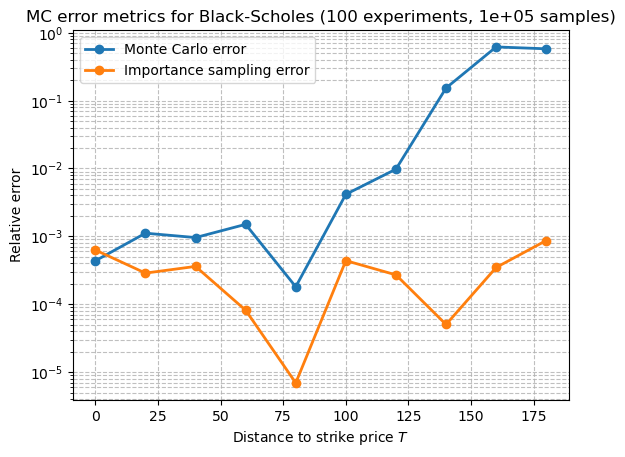

In [3]:
delta = step*np.arange(maxiter)
K = S0 + delta
MC_price = np.zeros(maxiter)
IS_price = np.zeros(maxiter)
CF_price = european_call_cf(S0,K,T,r,sigma) # Exact values
a = np.log(K/S0)/(sigma*np.sqrt(T))

for i, k in enumerate(K):
    MC_price[i] = np.mean(european_call_mc(S0, k, T, r, sigma, n, exp))
    IS_price[i] = np.mean(european_call_is(S0, k, T, r, sigma, a[i], n, exp))

MC_error = np.abs(MC_price - CF_price)/CF_price
IS_error = np.abs(IS_price - CF_price)/CF_price

plt.semilogy(delta,MC_error,'o-',lw=2,label='Monte Carlo error')
plt.semilogy(delta,IS_error,'o-',lw=2,label='Importance sampling error')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Distance to strike price $T$')
plt.ylabel('Relative error')
plt.title(f'MC error metrics for Black-Scholes ({exp} experiments, {n:.0e} samples)')
plt.legend()
plt.show()

This plot shows that gaussian mean shift consistently provides more precise estimates, due to the increased amount of samples being accounted for. However, the biggest difference of importance sampling should be the considerable reduction in variance.

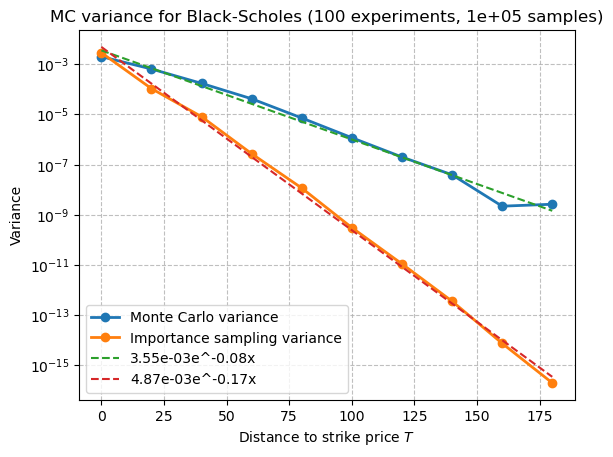

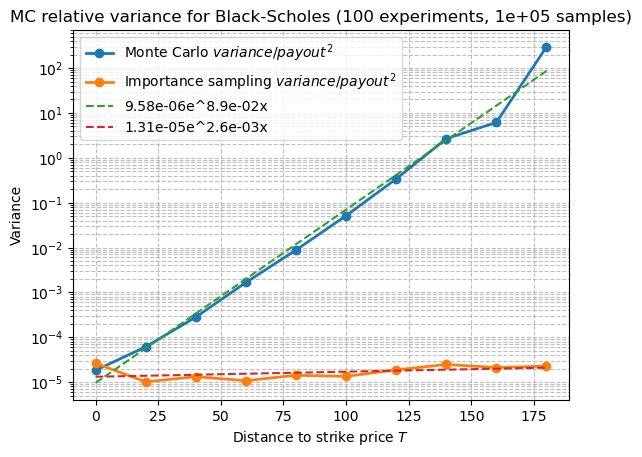

In [16]:
delta = step*np.arange(maxiter)
K = S0 + delta
MC_var = np.zeros(maxiter)
IS_var = np.zeros(maxiter)
CF_price = european_call_cf(S0,K,T,r,sigma)
a = np.log(K/S0)/(sigma*np.sqrt(T))

for i, k in enumerate(K):
    MC_var[i] = np.var(european_call_mc(S0, k, T, r, sigma, n, exp),ddof=1)
    IS_var[i] = np.var(european_call_is(S0, k, T, r, sigma, a[i], n, exp),ddof=1)

plt.semilogy(delta,MC_var,'o-',lw=2,label='Monte Carlo variance')
plt.semilogy(delta,IS_var,'o-',lw=2,label='Importance sampling variance')

a, C = logyfit(delta, MC_var)
ref = C * np.exp(delta * a)
plt.semilogy(delta, ref, '--', label=f'{C:.2e}e^{a:.2f}x')

a, C = logyfit(delta, IS_var)
ref = C * np.exp(delta * a)
plt.semilogy(delta, ref, '--', label=f'{C:.2e}e^{a:.2f}x')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Distance to strike price $T$')
plt.ylabel('Variance')
plt.title(f'MC variance for Black-Scholes ({exp} experiments, {n:.0e} samples)')
plt.legend()
plt.show()

plt.semilogy(delta,MC_var/CF_price**2,'o-',lw=2,label='Monte Carlo $variance/payout^2$')
plt.semilogy(delta,IS_var/CF_price**2,'o-',lw=2,label='Importance sampling $variance/payout^2$')

a, C = logyfit(delta, MC_var/CF_price**2)
ref = C * np.exp(delta * a)
plt.semilogy(delta, ref, '--', label=f'{C:.2e}e^{a:.1e}x')

a, C = logyfit(delta, IS_var/CF_price**2)
ref = C * np.exp(delta * a)
plt.semilogy(delta, ref, '--', label=f'{C:.2e}e^{a:.1e}x')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Distance to strike price $T$')
plt.ylabel('Variance')
plt.title(f'MC relative variance for Black-Scholes ({exp} experiments, {n:.0e} samples)')
plt.legend()
plt.show()